## Import Libraries

In [29]:
import mujoco
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import os, json, imageio, base64
from scipy.spatial.transform import Rotation
from IPython.display import display, HTML
from PIL import Image as PILImage, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys
from shared_tracker import RunLogger
from helper import plot_loss_reward, record_all_seeds, plot_episode_traces
# Change this to your own path if needed.
XML_PATH     = "segway_2.xml"

SAVE_DIR     = "SavedSeeds"

TRAIN_SEEDS  = [42]
VERIFY_SEEDS = [788, 999, 555, 321, 444]
os.makedirs(SAVE_DIR, exist_ok=True)

## Segway starts from the ground

In [30]:
def get_ground_contact_z(xml_path, tilt=0.0):
    """
    Find the correct z so the segway sits ON the ground
    at the given tilt — not floating, not underground.
    """
    model = mujoco.MjModel.from_xml_path(xml_path)
    data  = mujoco.MjData(model)

    # set tilt at high z, drop freely with no control
    mujoco.mj_resetData(model, data)
    rot  = Rotation.from_euler('y', tilt)
    quat = rot.as_quat()
    data.qpos[3:7] = [quat[3], quat[0], quat[1], quat[2]]
    data.qpos[2]   = 2.0   # start well above ground
    data.qvel[:]   = 0.0
    mujoco.mj_forward(model, data)

    # drop until it settles — no control, gravity only
    for _ in range(2000):
        data.ctrl[:] = 0.0
        mujoco.mj_step(model, data)
        # settled when vertical velocity near zero and low height
        if abs(data.qvel[2]) < 0.001 and data.qpos[2] < 0.5:
            break

    return data.qpos[2]


# find ground z for different tilts
print("Ground contact heights:")
for tilt in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    z = get_ground_contact_z(XML_PATH, tilt)
    print(f"  tilt={tilt:.1f} rad "
          f"({np.degrees(tilt):.1f}°) → z={z:.4f}")
    
    
# run once at startup — build lookup table
print("Building ground contact lookup table...")
GROUND_Z_TABLE = {}
for tilt in np.arange(0.0, 1.1, 0.05):
    GROUND_Z_TABLE[round(tilt, 2)] = \
        get_ground_contact_z(XML_PATH, tilt)
    GROUND_Z_TABLE[round(-tilt, 2)] = \
        GROUND_Z_TABLE[round(tilt, 2)]  # symmetric
print("Done.")
print(GROUND_Z_TABLE)


def get_z_for_tilt(tilt):
    """Look up nearest precomputed z for given tilt."""
    key = round(round(abs(tilt) / 0.05) * 0.05, 2)
    key = min(key, 1.0)
    return GROUND_Z_TABLE.get(key, GROUND_Z_TABLE[0.0])


model    = mujoco.MjModel.from_xml_path(XML_PATH)

# Joint lookup (do once)
rw_joint_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_JOINT, "joint_reaction_wheel")
rw_qvel_addr = model.jnt_dofadr[rw_joint_id]
print(f"RW joint id={rw_joint_id}, qvel addr={rw_qvel_addr}")

Ground contact heights:
  tilt=0.0 rad (0.0°) → z=0.0730
  tilt=0.1 rad (5.7°) → z=0.0740
  tilt=0.2 rad (11.5°) → z=0.0740
  tilt=0.3 rad (17.2°) → z=0.0740
  tilt=0.4 rad (22.9°) → z=0.0740
  tilt=0.5 rad (28.6°) → z=0.0740
Building ground contact lookup table...
Done.
{np.float64(0.0): np.float64(0.07301796866829649), np.float64(0.05): np.float64(0.07398984116042481), np.float64(-0.05): np.float64(0.07398984116042481), np.float64(0.1): np.float64(0.07398862916249783), np.float64(-0.1): np.float64(0.07398862916249783), np.float64(0.15): np.float64(0.07398702063271577), np.float64(-0.15): np.float64(0.07398702063271577), np.float64(0.2): np.float64(0.07398811880174053), np.float64(-0.2): np.float64(0.07398811880174053), np.float64(0.25): np.float64(0.07398838358012261), np.float64(-0.25): np.float64(0.07398838358012261), np.float64(0.3): np.float64(0.07398765299807862), np.float64(-0.3): np.float64(0.07398765299807862), np.float64(0.35): np.float64(0.07398694924527938), np.float64(-0.

## Other functions

In [31]:
def get_obs(data):
    quat  = data.qpos[3:7]
    rot   = Rotation.from_quat(
        [quat[1], quat[2], quat[3], quat[0]])
    theta = rot.as_euler('xyz')[1]
    psi = rot.as_euler('xyz')[2]
    rw_w = data.qvel[7] # reaction wheel sped in rad/s
    # [x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot]
    return np.array([data.qpos[0], data.qvel[0], data.qpos[1], data.qvel[1],
                     theta, data.qvel[4], psi, data.qvel[5], rw_w],
                    dtype=np.float32)


def normalize_obs(obs):
    x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs
    return np.array([
        np.clip(x         / 2.4,  -1, 1),
        np.clip(x_dot     / 5.0,  -1, 1),
        np.clip(y         / 2.4,  -1, 1),
        np.clip(y_dot     / 5.0,  -1, 1),
        np.clip(theta     / 1.57, -1, 1),
        np.clip(theta_dot / 5.0,  -1, 1),
        np.clip(psi       / 1.57, -1, 1),
        np.clip(psi_dot   / 5.0,  -1, 1),
        np.clip(rw_w      / 100.0, -1, 1)
    ], dtype=np.float32)

## PPO and reward function

In [ ]:
class NavPPO(nn.Module):
    def __init__(self, torque_max=5.0):
        super().__init__()
        self.torque_max = torque_max
        self.net = nn.Sequential(
            nn.Linear(11, 512), nn.Tanh(),      # Input: 9D obs + dist + heading error = 10            
            nn.Linear(512, 512), nn.Tanh(),
            nn.Linear(512, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
        )
        self.actor_mean    = nn.Linear(128, 2)
        self.actor_log_std = nn.Parameter(
            torch.tensor([-0.5]))   # std≈0.6
        self.critic        = nn.Linear(128, 1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, 0.5)
                nn.init.zeros_(m.bias)
        nn.init.orthogonal_(
            self.actor_mean.weight, 0.01)

    def forward(self, x):
        s = self.net(x)
        return self.actor_mean(s), self.critic(s)

    def get_action(self, obs, goal_x, goal_y,
                deterministic=False):
        # Compute distance to goal
        dx = goal_x - obs[0]
        dy = goal_y - obs[2]
        dist = np.sqrt(dx**2 + dy**2)
        dist_norm = float(np.clip(dist / 5., -1, 1))
        
        # Compute desired heading and heading error
        desired_heading = np.arctan2(dy, dx)
        psi = obs[6]  # current yaw
        heading_error = desired_heading - psi
        # Wrap heading_error to [-pi, pi]
        heading_error = np.arctan2(np.sin(heading_error), np.cos(heading_error))
        heading_error_norm = float(np.clip(heading_error / np.pi, -1, 1))

        inp = np.array([
            *normalize_obs(obs), dist_norm, heading_error_norm],
            dtype=np.float32)
        t         = torch.FloatTensor(inp)
        mean, val = self(t)
        std       = self.actor_log_std.exp().clamp(0.1, 2.0)
        dist      = torch.distributions.Normal(mean, std)
        raw       = mean if deterministic else dist.rsample()
        logp      = dist.log_prob(raw).sum(-1)
        torques    = torch.tanh(raw) * self.torque_max
        # torque[0] is wheel torque, torque[1] is reaction wheel torque
        return torques[0].item(), torques[1].item(), logp, val

def nav_reward(obs, prev_pos, goal_x, goal_y, at_goal, done, step):
    x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs

    if done:    return -30.0
    if at_goal: return 100.0

    # Current distance to goal
    curr_dist = np.sqrt((x - goal_x)**2 + (y - goal_y)**2)
    # Previous distance to goal
    prev_dist = np.sqrt((prev_pos[0] - goal_x)**2 + (prev_pos[1] - goal_y)**2)

    # progress moving closer to goal
    r = (prev_dist - curr_dist) * 20.0

    # continuous pull — penalise being far from goal
    r -= curr_dist * 0.1
    
    r += 0.03  # ~+60 over a 3000-step episode for staying up
    #small penalty for reaction wheel above n rev/s
    n = 3
    r -= max(0, abs(rw_w) - 6.28*n) * 0.01  # penalty starts above ~1 rev/s
    # stability
    if abs(theta) > 0.20:
        r -= (abs(theta) - 0.2) * 5.0

    return float(r)

## Train PPO (Single)

In [ ]:
# ==========================================================================
# PPO  —  instrumented train_nav.
# Replace your existing PPO train_nav with this. Changes marked  # <-- NEW
# Same step budget and same RunLogger call as SAC, so logs are comparable.
# Everything else is your original PPO logic, untouched.
# ==========================================================================
def train_nav(x_start=0.0, x_goal=2.0, y_start=0.0, y_goal=2.0,
              seed=42, tag="nav_v4",
              max_steps=600_000):              # <-- NEW: step budget (was max_episodes)
    torch.manual_seed(seed); np.random.seed(seed)

    net       = NavPPO(torque_max=5.0)
    optimizer = optim.Adam(net.parameters(), lr=3e-4, eps=1e-5)
    #Hyperparameters:
    # STEPS: how many steps of interaction (rollout) before each update
    # EPOCHS: how many passes of PPO update to make per rollout
    # CLIP: PPO clipping parameter — how far new policy can deviate from old one

    STEPS, EPOCHS, CLIP   = 2048, 10, 0.2
    GAMMA, LAM, MB        = 0.99, 0.95, 256
    ENT_START, ENT_END    = 0.01, 0.002
    ENT_DECAY             = 3000
    MAX_EP_STEPS          = 3000
    #max possible sim time based on step limit and timestep size = 3000 steps * 0.002s/step
    rewards=[]; losses=[]; best_avg=-9999; best_weights=None

    def gae(rews, vals, dones, nv):
        adv,g=[],0
        for r,v,d in zip(reversed(rews),reversed(vals),reversed(dones)):
            delta=r+GAMMA*nv*(1-d)-v; g=delta+GAMMA*LAM*(1-d)*g
            adv.insert(0,g); nv=v
        return adv

    model = mujoco.MjModel.from_xml_path(XML_PATH)
    data  = mujoco.MjData(model)

    def reset_env():
        mujoco.mj_resetData(model,data)
        data.qpos[0]=x_start; data.qpos[1]=y_start
        data.qpos[2]=get_z_for_tilt(0.0); data.qpos[3:7]=[1,0,0,0]
        data.qvel[:]=0.0; data.qvel[4]=np.random.uniform(-0.01,0.01)
        mujoco.mj_forward(model,data); return get_obs(data)

    def env_step(wheel_torque, reaction_torque):
        u_wheel=float(np.clip(wheel_torque,-5.,5.)); u_react=float(np.clip(reaction_torque,-5.,5.))
        data.ctrl[0]=-u_wheel; data.ctrl[1]=u_react
        mujoco.mj_step(model,data); obs=get_obs(data); x,x_dot,y,y_dot,theta,theta_dot,psi,psi_dot, rw_w =obs
        dist_to_goal = np.sqrt((x-x_goal)**2 + (y-y_goal)**2)
        done=(abs(x)>2.8 or abs(y)>2.8 or abs(theta)>0.5)
        at_goal=(dist_to_goal<0.15 and abs(theta)<0.25)
        return obs,done,at_goal

    logger = RunLogger("PPO", seed, log_every_steps=2000)   # <-- NEW


    obs=reset_env(); ep_total=0.0; prev_pos=np.array([obs[0], obs[2]])
    ep_count=0; ep_step=0; total_steps=0                   # <-- NEW: total_steps
    ENT=ENT_START


    print(f"\nPPO | A=({x_start},{y_start}) -> B=({x_goal},{y_goal}) | budget={max_steps:,} steps")
    print(f"{'Steps':>9} | {'Ep':>5} | {'Avg100':>8} | {'Rec%':>6} | {'Loss':>8} | {'std':>5}")
    print("-"*62)

    while total_steps < max_steps:                          # <-- NEW: step budget
        #ol: observations, al: actions, rl: rewards, vl: values, ll: logprobs, dl: dones
        ol,al,rl,vl,ll,dl=[],[],[],[],[],[]
        ep_rewards=[]; ep_arrived_flags=[]                  # <-- NEW: track arrivals
######################
        for _ in range(STEPS):
            with torch.no_grad():
                w_torque,r_torque,logp,value = net.get_action(obs,x_goal,y_goal,deterministic=False)
            ep_step+=1; total_steps+=1                            # <-- NEW: track total steps
            obs2,done,at_goal = env_step(w_torque,r_torque)
            r=nav_reward(obs2,prev_pos,x_goal,y_goal,at_goal,done,ep_step)
            ep_total+=r; prev_pos=np.array([obs2[0], obs2[2]])
            dx = x_goal - obs[0]; dy = y_goal - obs[2]
            dist = np.sqrt(dx**2 + dy**2); dist_norm = float(np.clip(dist / 5., -1, 1))
            desired_heading = np.arctan2(dy, dx); heading_error = desired_heading - obs[6]
            heading_error = np.arctan2(np.sin(heading_error), np.cos(heading_error))
            heading_error_norm = float(np.clip(heading_error / np.pi, -1, 1))
            inp=np.array([*normalize_obs(obs), dist_norm, heading_error_norm],dtype=np.float32)
            ol.append(inp); al.append([w_torque, r_torque]); rl.append(r)
            vl.append(value.item())
            ll.append(logp.item())
            dl.append(float(done or at_goal))
            obs=obs2
            timeout=(ep_step>=MAX_EP_STEPS)
            ################## Idk past here man ##########
            if done or at_goal or timeout:
                if timeout and not at_goal: rl[-1]-=5.0
                ep_rewards.append(ep_total)
                ep_arrived_flags.append(at_goal)            # <-- NEW
                ep_total=0.0; ep_step=0; ep_count+=1
                ENT=ENT_START+(ENT_END-ENT_START)*min(1.0,ep_count/ENT_DECAY)
                obs=reset_env(); prev_pos=np.array([obs[0], obs[2]])

        # PPO Update #
        with torch.no_grad():
            dx = x_goal - obs[0]; dy = y_goal - obs[2]
            dist = np.sqrt(dx**2 + dy**2)
            dist_norm = float(np.clip(dist / 5., -1, 1))
            desired_heading = np.arctan2(dy, dx)
            heading_error = desired_heading - obs[6]
            heading_error = np.arctan2(np.sin(heading_error), np.cos(heading_error))
            heading_error_norm = float(np.clip(heading_error / np.pi, -1, 1))
            inp=np.array([*normalize_obs(obs), dist_norm, heading_error_norm],dtype=np.float32)
            _,nv=net(torch.FloatTensor(inp))
        advantages=gae(rl,vl,dl,nv.item())
        returns=[a+v for a,v in zip(advantages,vl)]
        n=len(ol)
        obs_t=torch.FloatTensor(np.array(ol)); act_t=torch.FloatTensor(al)
        ret_t=torch.FloatTensor(returns); adv_t=torch.FloatTensor(advantages)
        logp_t=torch.FloatTensor(ll)
        adv_t=((adv_t-adv_t.mean())/(adv_t.std()+1e-8))
        batch_loss=0.0
        for _ in range(EPOCHS):
            idx=torch.randperm(n)
            for s in range(0,n,MB):
                i=idx[s:s+MB]
                mean,vals=net(obs_t[i])
                std=net.actor_log_std.exp().clamp(0.1,2.0)
                dist=torch.distributions.Normal(mean,std)
                raw=torch.atanh((act_t[i]/net.torque_max).clamp(-0.999,0.999))
                nlp=dist.log_prob(raw).sum(-1); ent=dist.entropy().mean()
                ratio=(nlp-logp_t[i]).exp().clamp(0.,10.)
                s1=ratio*adv_t[i]; s2_=torch.clamp(ratio,1-CLIP,1+CLIP)*adv_t[i]
                loss=(-torch.min(s1,s2_).mean()
                      +0.5*nn.MSELoss()(vals.squeeze(),ret_t[i])-ENT*ent)
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(net.parameters(),0.5); optimizer.step()
                with torch.no_grad(): net.actor_log_std.clamp_(-1.5,0.7)
                batch_loss+=loss.item()

        rewards.extend(ep_rewards); losses.append(batch_loss)

        # <-- NEW: log each finished episode in this rollout, identical to SAC
        for ret, arr in zip(ep_rewards, ep_arrived_flags):
            avg, rp = logger.episode_end(total_steps, ep_count, ret, arr, batch_loss)

        if ep_rewards:
            cur_std=float(net.actor_log_std.exp().item())
            icon="✅" if avg>0 else "🔄" if avg>-20 else "⏳"
            print(f"{total_steps:>9,} | {ep_count:>5} | {avg:>8.2f} | "
                  f"{rp:>5.1f}% | {batch_loss:>8.3f} | {cur_std:.3f} {icon}", flush=True)
            if avg>best_avg:
                best_avg=avg
                best_weights={k:v.clone() for k,v in net.state_dict().items()}
                torch.save(net.state_dict(), f"{SAVE_DIR}/nav_{tag}.pth")


    if best_weights: net.load_state_dict(best_weights)
    return net, rewards, losses, logger            # <-- NEW: also return logger

## Training and Verifying PPO with multiple seeds

In [67]:
def train_one_verify_many(algo_label,
                          train_seed   = 42,
                          verify_seeds = (788, 999, 555, 321, 444,
                                          123, 777, 256, 512, 111),
                          x_start=0.0, x_goal=2.0,
                          y_start=0.0, y_goal=2.0,
                          step_budget=500_000):
    verify_seeds = list(verify_seeds)

    # ---- 1. TRAIN on the single train_seed ----
    print(f"\n{'='*60}\n  {algo_label}  TRAIN seed = {train_seed}\n{'='*60}")
    net, rewards, losses, logger = train_nav(
        x_start=x_start, x_goal=x_goal, y_start=y_start, y_goal=y_goal,
        seed=train_seed, tag=f"cmp_seed{train_seed}",
        max_steps=step_budget)

    # ---- 2. eval helper (deterministic) ----
    def eval_policy(net, seed, n=20):
        torch.manual_seed(seed); np.random.seed(seed)
        model=mujoco.MjModel.from_xml_path(XML_PATH); data=mujoco.MjData(model)
        strict=loose=fell=0; max_xs=[]; times=[]
        for _ in range(n):
            mujoco.mj_resetData(model,data)
            data.qpos[0]=x_start
            data.qpos[1]=y_start 
            data.qpos[2]=get_z_for_tilt(0.0)
            data.qpos[3:7]=[1,0,0,0]; data.qvel[:]=0.0
            data.qvel[4]=np.random.uniform(-0.02,0.02)
            mujoco.mj_forward(model,data); obs=get_obs(data); mx=0.0; end="timeout"
            # This loop steps the environment forward using the policy's actions, without exploration noise (deterministic=True).
            for step in range(3000):
                with torch.no_grad():
                    w_t, r_t, _,_=net.get_action(obs,x_goal, y_goal, deterministic=True)
                data.ctrl[0]=-float(np.clip(w_t,-5,5))
                data.ctrl[1]=float(np.clip(r_t,-5,5))
                mujoco.mj_step(model,data)
                obs=get_obs(data)

                #x,_,th,_=obs
                x,_,y,_,th,_,_,_,_=obs
                #mx is the max distance from origin during the episode, used to measure how far it strayed
                mx=max(mx,np.sqrt(x**2+y**2))

                # Rewritten for 2D case
                if abs(x)>2.8 or abs(y)>2.8 or abs(th)>0.5: end="fell"; break
                if (abs(x-x_goal)<0.10 or abs(y-y_goal)<0.10) and abs(th)<0.35:
                    end="strict"; times.append(step*model.opt.timestep); break
                elif (abs(x-x_goal)<0.25 or abs(y-y_goal)<0.25) and abs(th)<0.35:
                    end="loose"; times.append(step*model.opt.timestep)
            strict+=end=="strict"; loose+=end=="loose"; fell+=end=="fell"
            max_xs.append(mx)
        return {"strict_pct":strict/n*100,"loose_pct":(strict+loose)/n*100,
                "fell_pct":fell/n*100,"avg_max_x":float(np.mean(max_xs)),
                "avg_time":float(np.mean(times)) if times else 999.0}

    # ---- 3. VERIFY the one policy on every verify seed ----
    print(f"\n  Verifying {algo_label} policy (trained on {train_seed}) "
          f"on {len(verify_seeds)} unseen seeds:")
    print(f"  {'Seed':>6} | {'Strict%':>8} | {'Loose%':>7} | {'Fell%':>6} | {'Time':>6}")
    print("  " + "-"*48)
    per_seed={}
    for vs in verify_seeds:
        r=eval_policy(net, vs); per_seed[vs]=r
        icon="✅" if r["strict_pct"]>=80 else "🔄" if r["strict_pct"]>=50 else "❌"
        print(f"  {vs:>6} | {r['strict_pct']:>7.0f}% | {r['loose_pct']:>6.0f}% | "
              f"{r['fell_pct']:>5.0f}% | {r['avg_time']:>5.1f}s {icon}")

    # ---- 4. aggregate across verify seeds ----
    summary={
        "train_seed":   train_seed,
        "verify_seeds": verify_seeds,
        "strict_pct":   float(np.mean([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "strict_std":   float(np.std ([per_seed[v]["strict_pct"] for v in verify_seeds])),
        "fell_pct":     float(np.mean([per_seed[v]["fell_pct"]   for v in verify_seeds])),
        "avg_time":     float(np.mean([per_seed[v]["avg_time"]
                                       for v in verify_seeds
                                       if per_seed[v]["avg_time"]<999] or [999])),
        "per_seed":     per_seed,
    }
    print(f"\n  {algo_label} verify avg: "
          f"{summary['strict_pct']:.1f}% ± {summary['strict_std']:.1f}%  strict  |  "
          f"{summary['fell_pct']:.1f}% fell")

    # ---- 5. save the log (this is the JSON you plot from) ----
    logger.save(SAVE_DIR, f"cmp_seed{train_seed}_v2", eval_results=summary)
    return net, logger, summary

# SAC notebook:   train_one_verify_many("SAC", train_seed=42)
# PPO notebook:    train_one_verify_many("PPO", train_seed=42)

## RUN ALL

### At 500,000 steps

In [68]:
net, logger, summary = train_one_verify_many("PPO", train_seed=42, step_budget=100000)


  PPO  TRAIN seed = 42

PPO | A=(0.0,0.0) -> B=(2.0,2.0) | budget=100,000 steps
    Steps |    Ep |   Avg100 |   Rec% |     Loss |   std
--------------------------------------------------------------
    2,048 |    29 |   -62.82 |   0.0% | 6009.516 | 0.612 ⏳
    4,096 |    61 |   -62.94 |   0.0% | 4303.471 | 0.609 ⏳
    6,144 |   102 |   -60.03 |   0.0% | 2783.420 | 0.610 ⏳
    8,192 |   139 |   -59.60 |   0.0% | 1719.627 | 0.612 ⏳
   10,240 |   176 |   -59.27 |   0.0% |  812.054 | 0.619 ⏳
   12,288 |   220 |   -56.19 |   0.0% |  235.053 | 0.629 ⏳
   14,336 |   274 |   -51.33 |   0.0% |  221.599 | 0.629 ⏳
   16,384 |   339 |   -47.13 |   0.0% |  121.744 | 0.615 ⏳
   18,432 |   403 |   -45.11 |   0.0% |   71.603 | 0.609 ⏳
   20,480 |   473 |   -44.15 |   0.0% |   42.264 | 0.610 ⏳
   22,528 |   552 |   -43.11 |   0.0% |   36.326 | 0.604 ⏳
   24,576 |   639 |   -41.47 |   0.0% |   27.029 | 0.602 ⏳
   26,624 |   733 |   -40.36 |   0.0% |   18.289 | 0.599 ⏳
   28,672 |   831 |   -40.02 |  

### At 2,000,000,000 steps

In [69]:
def record_all_seeds_2D(nav_net, train_seeds=[42], verify_seeds=[788,999,555,321,444],
                     x_start=0.0, x_goal=2.0, y_start=0.0, y_goal=2.0, max_steps=3000,
                     XML_PATH=None, get_z_for_tilt=None, get_obs=None,
                     playback_speed=1, speed_mode="skip"):
    """Render and save videos for all seeds, with on-screen annotations (2D case).
    
    Args:
        nav_net: Trained policy network
        train_seeds: List of training seed values
        verify_seeds: List of verification seed values
        x_start: Starting x position
        x_goal: Goal x position
        y_start: Starting y position
        y_goal: Goal y position
        max_steps: Maximum steps per episode
        XML_PATH: Path to XML model file
        get_z_for_tilt: Function to get z position for tilt
        get_obs: Function to get observation from data
        playback_speed: Integer k — speed multiplier for output video.
        speed_mode:     "skip" = keep every k-th frame (smaller file, same fps).
                        "fps"  = keep all frames, multiply fps by k.
    """
    if XML_PATH is None or get_z_for_tilt is None or get_obs is None:
        raise ValueError("Must provide XML_PATH, get_z_for_tilt, and get_obs functions")
    if playback_speed < 1 or not isinstance(playback_speed, int):
        raise ValueError("playback_speed must be a positive integer")
    if speed_mode not in ("skip", "fps"):
        raise ValueError("speed_mode must be 'skip' or 'fps'")
    
    BASE_FPS = 30
    output_fps = BASE_FPS * playback_speed if speed_mode == "fps" else BASE_FPS

    model    = mujoco.MjModel.from_xml_path(XML_PATH)
    data     = mujoco.MjData(model)
    dt       = model.opt.timestep
    print(f"Time step = {dt:.4f}s, base FPS = {1/dt:.1f}, output FPS = {output_fps} (mode={speed_mode})")
    renderer = mujoco.Renderer(model, height=480, width=640)

    # Overhead camera for 2D visualization
    cam = mujoco.MjvCamera()
    cam.type = mujoco.mjtCamera.mjCAMERA_FREE
    cam.lookat = np.array([(x_start + x_goal) / 2.0, (y_start + y_goal) / 2.0, 0.3])
    cam.distance = 6.0
    cam.azimuth = 90
    cam.elevation = -45  # steeper angle to see 2D ground plane better

    # 2D minimap pixel bounds (for the XY minimap overlay)
    MAP_X0, MAP_Y0 = 10, 320          # top-left corner of minimap on frame
    MAP_W,  MAP_H  = 120, 120         # minimap size in pixels
    MAP_MARGIN     = 0.5              # world-unit padding around goal/start

    def world_to_map(wx, wy):
        """Convert world (x,y) to minimap pixel coords."""
        wx_min = min(x_start, x_goal) - MAP_MARGIN
        wx_max = max(x_start, x_goal) + MAP_MARGIN
        wy_min = min(y_start, y_goal) - MAP_MARGIN
        wy_max = max(y_start, y_goal) + MAP_MARGIN
        px = MAP_X0 + int((wx - wx_min) / (wx_max - wx_min) * MAP_W)
        py = MAP_Y0 + MAP_H - int((wy - wy_min) / (wy_max - wy_min) * MAP_H)  # flip y
        return px, py

    # Goal distance for progress bar normalisation
    goal_dist = np.sqrt((x_goal - x_start)**2 + (y_goal - y_start)**2)
    all_seeds = [(s, "TRAIN") for s in train_seeds] + [(s, "VERIFY") for s in verify_seeds]
    print("Recording seeds...")

    for seed, role in all_seeds:
        torch.manual_seed(seed); np.random.seed(seed)
        mujoco.mj_resetData(model, data)

        # 2D initial position
        data.qpos[0] = x_start
        data.qpos[1] = y_start
        data.qpos[2] = get_z_for_tilt(0.0)
        data.qpos[3:7] = [1, 0, 0, 0]
        data.qvel[:] = 0.0
        mujoco.mj_forward(model, data)

        obs = get_obs(data)
        frames = []
        strict = arrived = fell = False

        for step in range(max_steps):
            with torch.no_grad():
                w_t, r_t, _, _ = nav_net.get_action(obs, x_goal, y_goal, deterministic=True)

            # ctrl[0] = wheel torque, ctrl[1] = reaction wheel torque
            data.ctrl[0] = -float(np.clip(w_t, -5, 5))
            data.ctrl[1] =  float(np.clip(r_t, -5, 5))
            mujoco.mj_step(model, data)
            obs = get_obs(data)

            # Unpack 2D obs: [x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot]
            x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs

            dist_to_goal = np.sqrt((x - x_goal)**2 + (y - y_goal)**2)
            fell    = abs(theta) > 0.5
            arrived = dist_to_goal < 0.25 and abs(theta) < 0.35
            strict  = dist_to_goal < 0.10 and abs(theta) < 0.35

            # ── Frame skip: only render/annotate on kept frames ───────────────
            # Always render the very last frame or terminal frames for clean endings
            is_terminal = strict or fell
            should_keep = (step % playback_speed == 0) or is_terminal

            if speed_mode == "skip" and not should_keep:
                if is_terminal:
                    frames += [frames[-1]] * 60
                    break
                continue  # skip rendering this frame entirely

            renderer.update_scene(data, camera=cam)
            img  = PILImage.fromarray(renderer.render())
            draw = ImageDraw.Draw(img)
            W, H = img.size

            # ── Progress bar (distance to goal) ──────────────────────────────
            prog = float(np.clip(1.0 - dist_to_goal / goal_dist, 0, 1))
            bw   = W - 40
            pcol = (0, 200, 0) if strict else (255, 140, 0) if arrived else (30, 100, 220)
            draw.rectangle([20, 8, W - 20, 28], fill=(40, 40, 40))
            draw.rectangle([20, 8, 20 + int(bw * prog), 28], fill=pcol)
            draw.text((22, 10),   "Start", fill=(255, 255, 255))
            draw.text((W - 50, 10), "Goal",  fill=(255, 255, 255))
            draw.text((W // 2 - 55, 10),
                      f"{prog*100:.0f}%  dist={dist_to_goal:.3f}m",
                      fill=(255, 255, 255))

            # ── Seed / role badge ─────────────────────────────────────────────
            badge_col = (0, 60, 140) if role == "TRAIN" else (100, 0, 140)
            draw.rectangle([8, 34, 170, 58], fill=badge_col)
            draw.text((12, 38), f"[{role}] seed={seed}", fill=(255, 255, 255))

            # ── Speed indicator ───────────────────────────────────────────────
            if playback_speed > 1:
                draw.rectangle([8, 62, 100, 82], fill=(60, 30, 0))
                draw.text((12, 65), f"▶▶ {playback_speed}x", fill=(255, 200, 50))

            # ── Status bar ───────────────────────────────────────────────────
            if strict:
                sc = (0, 120, 0)
                st = f"✓ STRICT  dist={dist_to_goal:.3f}m  t={step*dt:.1f}s"
            elif arrived:
                sc = (120, 100, 0)
                st = f"~ LOOSE   dist={dist_to_goal:.3f}m  t={step*dt:.1f}s"
            elif fell:
                sc = (140, 0, 0)
                st = f"✗ FELL    θ={np.degrees(theta):.1f}°  t={step*dt:.1f}s"
            else:
                sc = (20, 20, 70)
                st = (f"x={x:+.2f} y={y:+.2f}  "
                      f"θ={np.degrees(theta):+.1f}°  ψ={np.degrees(psi):+.1f}°  "
                      f"wT={w_t:+.1f} rT={r_t:+.1f}  t={step*dt:.1f}s")
            draw.rectangle([175, 34, W - 8, 58], fill=sc)
            draw.text((178, 38), st, fill=(255, 255, 255))

            # ── 2D minimap ───────────────────────────────────────────────────
            # Background
            draw.rectangle([MAP_X0, MAP_Y0, MAP_X0 + MAP_W, MAP_Y0 + MAP_H],
                           fill=(20, 20, 40), outline=(150, 150, 150), width=2)
            draw.text((MAP_X0 + 2, MAP_Y0 + 2), "top-down", fill=(180, 180, 180))

            # Start marker (blue A)
            ax, ay = world_to_map(x_start, y_start)
            draw.ellipse([ax-8, ay-8, ax+8, ay+8], fill=(50, 100, 220), outline=(255,255,255), width=1)
            draw.text((ax-4, ay-6), "A", fill=(255, 255, 255))

            # Goal marker (green B)
            bx, by = world_to_map(x_goal, y_goal)
            draw.ellipse([bx-8, by-8, bx+8, by+8], fill=(0, 180, 70), outline=(255,255,255), width=1)
            draw.text((bx-4, by-6), "B", fill=(255, 255, 255))

            # Robot position + heading arrow
            rx, ry = world_to_map(float(np.clip(x, x_start - MAP_MARGIN, x_goal + MAP_MARGIN)),
                                  float(np.clip(y, y_start - MAP_MARGIN, y_goal + MAP_MARGIN)))
            rcol = (0, 220, 100) if strict else (255, 210, 0) if arrived else (220, 80, 80) if fell else (255, 255, 255)
            draw.ellipse([rx-6, ry-6, rx+6, ry+6], fill=rcol, outline=(50,50,50), width=1)
            # Heading arrow using yaw (psi)
            arrow_len = 12
            ax_tip = rx + int(arrow_len * np.cos(psi))
            ay_tip = ry - int(arrow_len * np.sin(psi))  # flip y for screen coords
            draw.line([(rx, ry), (ax_tip, ay_tip)], fill=(255, 100, 100), width=2)

            frames.append(np.array(img))
            if strict or fell:
                frames += [frames[-1]] * 60
                break

        result = "STRICT" if strict else "FELL" if fell else f"LOOSE@({x:.2f},{y:.2f})m"
        print(f"  [{role}] seed={seed}: {result}")

        fname = f"nav_ppo_{role.lower()}_seed{seed}.mp4"
        imageio.mimsave(fname, frames, fps=30)
        sz = os.path.getsize(fname) // 1024
        print(f"    saved {fname} ({sz} KB)")

        b64 = base64.b64encode(open(fname, "rb").read()).decode()
        display(HTML(f'<b>[{role}] Seed {seed} — {result}</b><br>'
                     f'<video width="640" height="480" controls autoplay loop>'
                     f'<source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))

    print("\nDone.")

In [70]:
record_all_seeds_2D(net, train_seeds=[42], verify_seeds=[788, 999, 555], x_goal=2.0,
                 y_goal = 2.0, playback_speed=1,
                XML_PATH=XML_PATH, get_z_for_tilt=get_z_for_tilt, get_obs=get_obs)

Time step = 0.0050s, base FPS = 200.0, output FPS = 30 (mode=skip)
Recording seeds...
  [TRAIN] seed=42: FELL
    saved nav_ppo_train_seed42.mp4 (30 KB)


  [VERIFY] seed=788: FELL
    saved nav_ppo_verify_seed788.mp4 (30 KB)


  [VERIFY] seed=999: FELL
    saved nav_ppo_verify_seed999.mp4 (30 KB)


  [VERIFY] seed=555: FELL
    saved nav_ppo_verify_seed555.mp4 (30 KB)



Done.


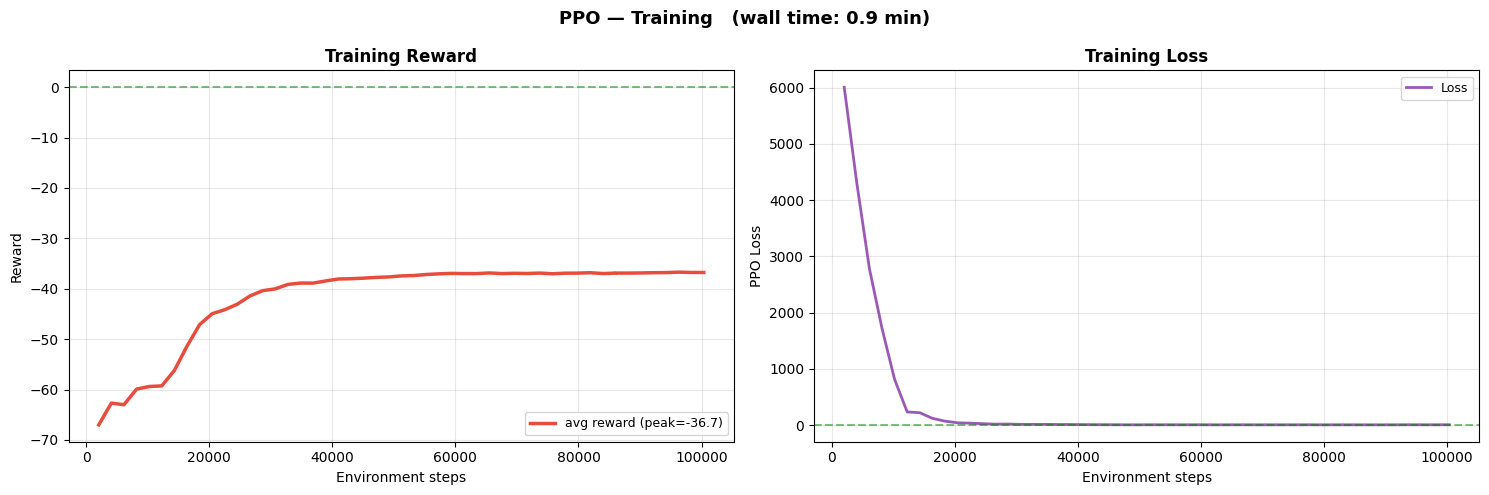

Saved: ppo_loss_reward.png
Training (wall) time: 0.9 min  (56 s)


In [71]:
plot_loss_reward(logger=logger, algo="PPO")

In [72]:
plot_episode_traces(net, algo="PPO",
                   XML_PATH=XML_PATH, get_z_for_tilt=get_z_for_tilt, get_obs=get_obs)

TypeError: NavPPO.get_action() missing 1 required positional argument: 'goal_y'

In [ ]:
# def train_nav(x_start=0.0, x_goal=2.0, y_start=0.0, y_goal=2.0,
#               seed=42, tag="nav_v4",
#               max_episodes=8000):
#     torch.manual_seed(seed)
#     np.random.seed(seed)

#     net       = NavPPO(torque_max=5.0)
#     optimizer = optim.Adam(
#         net.parameters(), lr=3e-4, eps=1e-5)

#     STEPS        = 2048
#     EPOCHS       = 10
#     CLIP         = 0.2
#     GAMMA        = 0.99
#     LAM          = 0.95
#     MB           = 256
#     ENT_START    = 0.01
#     ENT_END   = 0.002
#     ENT_DECAY = 3000   # episodes
#     MAX_EP_STEPS = 3000
    
    

#     rewards      = []
#     losses       = []
#     best_avg     = -9999
#     best_weights = None

#     def gae(rews, vals, dones, nv):
#         adv, g = [], 0
#         for r, v, d in zip(
#                 reversed(rews),
#                 reversed(vals),
#                 reversed(dones)):
#             delta = r + GAMMA*nv*(1-d) - v
#             g     = delta + GAMMA*LAM*(1-d)*g
#             adv.insert(0, g); nv = v
#         return adv

#     model = mujoco.MjModel.from_xml_path(XML_PATH)
#     data  = mujoco.MjData(model)
#     dt    = model.opt.timestep

#     def reset_env():
#         mujoco.mj_resetData(model, data)
#         data.qpos[0]   = x_start # start at A
#         data.qpos[1]   = 0.0 # 
#         data.qpos[2]   = get_z_for_tilt(0.0) #
#         data.qpos[3:7] = [1, 0, 0, 0] # 
#         data.qvel[:]   = 0.0 # start stationary
#         data.qvel[4]   = np.random.uniform(
#             -0.01, 0.01) # small random initial tilt velocity
#         mujoco.mj_forward(model, data)
#         return get_obs(data)

#     def env_step(wheel_torque, reaction_torque):
#         u_wheel = float(np.clip(wheel_torque, -5., 5.))
#         u_react = float(np.clip(reaction_torque, -5., 5.))
#         data.ctrl[0] = -u_wheel    # ← sign from verify_signs
#         data.ctrl[1] = u_react
#         mujoco.mj_step(model, data)
#         obs            = get_obs(data)
#         x, x_dot, y, y_dot, theta, theta_dot, psi, psi_dot, rw_w = obs
#         dist_to_goal = np.sqrt((x - x_goal)**2 + (y - y_goal)**2)
#         goal_dist_to_origin = np.sqrt(x_goal**2 + y_goal**2)
#         done    = (dist_to_goal     > (1.5*goal_dist_to_origin) or abs(theta) > 0.5)
#         at_goal = (dist_to_goal < (0.1*goal_dist_to_origin) and abs(theta) < 0.25)   # ← must be upright at B
#         return obs, done, at_goal

#     obs          = reset_env()
#     ep_total     = 0.0
#     prev_pos     = np.array([obs[0], obs[2]])
#     ep_count     = 0
#     arrivals     = 0
#     from collections import deque
#     recent_arrivals = deque(maxlen=200)
#     rollout      = 0
#     ep_step      = 0

#     print(f"\nPure PPO Navigation | "
#           f"A={x_start}m → B={x_goal}m")
#     print(f"  No PID — PPO controls torque directly")
#     print(f"  torque ∈ [-5, +5] Nm\n")
    
#     print(f"{'Roll':>6} | {'Ep':>5} | "
#         f"{'Avg':>8} | {'Rec%':>6} | "
#         f"{'Loss':>8} | {'std':>5}")
#     print("-" * 50)

#     ENT = ENT_START
#     while ep_count < max_episodes:
#         ol,al,rl,vl,ll,dl = [],[],[],[],[],[]
#         ep_rewards = []

#         for _ in range(STEPS):
#             with torch.no_grad():
#                 wheel_torque, reaction_torque, logp, value = net.get_action(obs, x_goal, y_goal, deterministic=False)

#             ep_step += 1
#             obs2, done, at_goal = env_step(wheel_torque, reaction_torque)

#             r = nav_reward(
#                 obs2, prev_pos, x_goal, y_goal,
#                 at_goal, done, ep_step)

#             ep_total += r
#             prev_pos    = np.array([obs2[0], obs2[2]])

#             inp = np.array([
#                 *normalize_obs(obs),
#                 np.clip(
#                     (x_goal-obs[0])/5.,-1,1)],
#                 dtype=np.float32)

#             ol.append(inp)
#             al.append([torque])
#             rl.append(r)
#             vl.append(value.item())
#             ll.append(logp.item())
#             dl.append(float(done or at_goal))

#             obs = obs2

#             timeout = (ep_step >= MAX_EP_STEPS)
#             if done or at_goal or timeout:
#                 if at_goal:
#                     arrivals += 1
#                 recent_arrivals.append(1 if at_goal else 0)
#                 if timeout and not at_goal:
#                     rl[-1] -= 5.0
#                 ep_rewards.append(ep_total)
#                 ep_total  = 0.0
#                 ep_step   = 0
#                 ep_count += 1
#                 ENT = ENT_START + (ENT_END - ENT_START) * min(1.0, ep_count / ENT_DECAY)
#                 obs       = reset_env()
#                 prev_pos    = np.array([obs[0], obs[2]])

#         # PPO update #########################
#         with torch.no_grad():
#             inp = np.array([
#                 *normalize_obs(obs),
#                 np.clip(
#                     (x_goal-obs[0])/5.,-1,1)],
#                 dtype=np.float32)
#             _, nv = net(torch.FloatTensor(inp))

#         advantages = gae(rl, vl, dl, nv.item())
#         returns    = [a+v for a,v
#                       in zip(advantages, vl)]
#         n = len(ol)

#         obs_t  = torch.FloatTensor(np.array(ol))
#         act_t  = torch.FloatTensor(al)
#         ret_t  = torch.FloatTensor(returns)
#         adv_t  = torch.FloatTensor(advantages)
#         logp_t = torch.FloatTensor(ll)
#         adv_t  = ((adv_t - adv_t.mean()) /
#                   (adv_t.std() + 1e-8))

#         batch_loss = 0.0
#         for _ in range(EPOCHS):
#             idx = torch.randperm(n)
#             for s in range(0, n, MB):
#                 i = idx[s:s+MB]
#                 mean, vals = net(obs_t[i])
#                 std  = net.actor_log_std.exp().clamp(0.1, 2.0)
#                 dist = torch.distributions.Normal(mean, std)
#                 raw  = torch.atanh(
#                     (act_t[i] / net.torque_max).clamp(-0.999, 0.999))
#                 nlp  = dist.log_prob(raw).sum(-1)
#                 ent  = dist.entropy().mean()
#                 ratio = (nlp - logp_t[i]).exp().clamp(0., 10.)
#                 s1   = ratio * adv_t[i]
#                 s2_  = torch.clamp(ratio, 1-CLIP, 1+CLIP) * adv_t[i]
#                 loss = (
#                     -torch.min(s1, s2_).mean()
#                     + 0.5 * nn.MSELoss()(vals.squeeze(), ret_t[i])
#                     - ENT * ent)
#                 optimizer.zero_grad()
#                 loss.backward()
#                 nn.utils.clip_grad_norm_(net.parameters(), 0.5)
#                 optimizer.step()
#                 with torch.no_grad():
#                     net.actor_log_std.clamp_(-1.5, 0.7)
#                 batch_loss += loss.item()

            

#         rollout += 1
#         rewards.extend(ep_rewards)
#         losses.append(batch_loss)

#         if ep_rewards:
#             avg = float(np.mean(
#                 rewards[-min(100,len(rewards)):]))
#             arr_pct    = arrivals / max(ep_count, 1) * 100
#             recent_pct = np.mean(recent_arrivals) * 100 if recent_arrivals else 0.0
#             cur_std = float(
#                 net.actor_log_std.exp().item())

#             if avg > best_avg:
#                 best_avg     = avg
#                 best_weights = {
#                     k: v.clone() for k,v
#                     in net.state_dict().items()}
#                 torch.save(
#                     net.state_dict(),
#                     f"{SAVE_DIR}/nav_{tag}.pth")

#             if rollout % 5 == 0:
#                 icon = ("✅" if avg >  0 else
#                         "🔄" if avg > -20 else
#                         "⏳")
#                 print(f"{rollout:>6} | "
#                     f"{ep_count:>5} | "
#                     f"{avg:>8.2f} | "
#                     f"{recent_pct:>5.1f}% | "  # ← recent window (replaces or adds to arr_pct)
#                     f"{batch_loss:>8.3f} | "
#                     f"{cur_std:.3f} {icon}",
#                     flush=True)

#     if best_weights:
#         net.load_state_dict(best_weights)
#     return net, rewards, losses


# nav_net, nav_rewards, nav_losses = train_nav(
#     x_start=0.0, x_goal=2.0,
#     seed=42, tag="nav_v4_1",
#     max_episodes=5000)